# HOMEWORK 14

In this homework you are going to build your first classifier for the CIFAR-10 dataset. This dataset contains 10 different classes and you can learn more about it [here](https://www.cs.toronto.edu/~kriz/cifar.html). This homework consists of the following tasks:
* Dataset inspection
* Building the network
* Training
* Evaluation

At the end, as usual, there will be a couple of questions for you to answer :-)

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D
from tensorflow.keras import Model
from time import time

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

### Step 0: Dataset Inspection

Load the dataset and make a quick inspection.

/tmp/ipykernel_379/2245765200.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(classes[int(y_train[idx])])


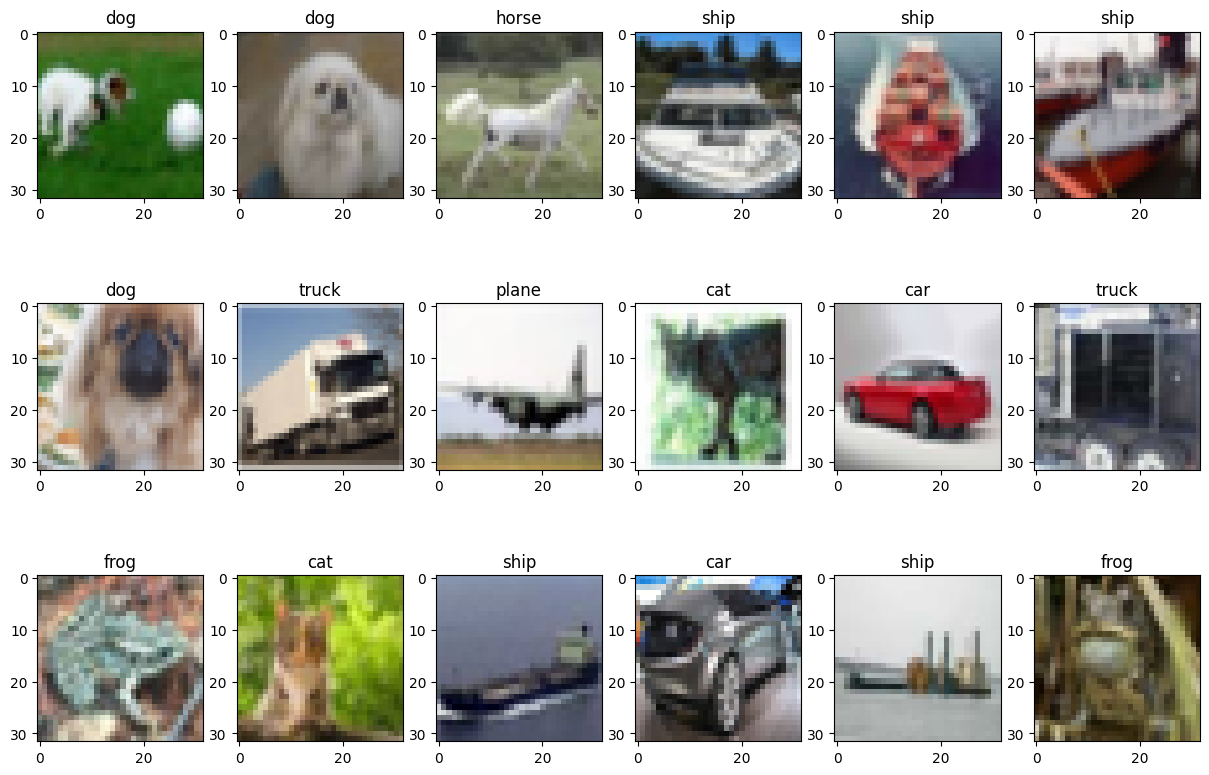

In [8]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Mapping from class ID to class name
classes = {0:'plane', 1:'car', 2:'bird', 3:'cat', 4:'deer',
           5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}

# Dataset params
num_classes = len(classes)
size = x_train.shape[1]

# Visualize random samples (as a plot with 3x6 samples)
for ii in range(18):
    plt.subplot(3,6,ii+1)
    # Pick a random sample
    idx = np.random.randint(0, x_train.shape[0])
    # Show the image and the label
    plt.imshow(x_train[idx, ...])
    plt.title(classes[int(y_train[idx])])

Compute the class histogram (you can visualize it if you want). Is the dataset balanced?

Hint: You might find [Counter](https://docs.python.org/3/library/collections.html#collections.Counter) tool useful. In any case, it's up to you how you compute the histogram.

In [9]:
# Compute the class histogram
from collections import Counter

# Flatten labels (з (50000,1) → (50000,))
labels = y_train.flatten()

# Count occurrences
hist = Counter(labels)

print(hist)

Counter({np.uint8(6): 5000, np.uint8(9): 5000, np.uint8(4): 5000, np.uint8(1): 5000, np.uint8(2): 5000, np.uint8(7): 5000, np.uint8(8): 5000, np.uint8(3): 5000, np.uint8(5): 5000, np.uint8(0): 5000})


### Step 1: Data Preparation

In this step, you'll need to prepare the data for training, i.e., you will have to normalize it and encode the labels as one-hot vectors.

In [10]:
# Normalization
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)
print(y_train.shape)

Train set:    50000 samples
Test set:     10000 samples
Sample dims:  (50000, 32, 32, 3)
(50000, 10)


### Step 2: Building the Classifier

Build the CNN for CIFAR10 classification. For starters, you can use the same network we used in the lesson for the MNIST problem.

In [11]:
# Build the classifier

inputs = Input(shape=(32, 32, 3))

x = Conv2D(32, (3,3), activation='relu')(inputs)
x = MaxPooling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)

x = Flatten()(x)

x = Dense(64, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)

# Show the model
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

### Step 3: Training

Compile the model and train it.

In [12]:
epochs = 25
batch_size = 128

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1
)

Epoch 1/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 169ms/step - accuracy: 0.3977 - loss: 1.6556 - val_accuracy: 0.4983 - val_loss: 1.4220
Epoch 2/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 156ms/step - accuracy: 0.5321 - loss: 1.3204 - val_accuracy: 0.5502 - val_loss: 1.2927
Epoch 3/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 152ms/step - accuracy: 0.5775 - loss: 1.1976 - val_accuracy: 0.5857 - val_loss: 1.1924
Epoch 4/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 163ms/step - accuracy: 0.6134 - loss: 1.1036 - val_accuracy: 0.6151 - val_loss: 1.1108
Epoch 5/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 156ms/step - accuracy: 0.6401 - loss: 1.0287 - val_accuracy: 0.6343 - val_loss: 1.0530
Epoch 6/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 159ms/step - accuracy: 0.6626 - loss: 0.9711 - val_accuracy: 0.6473 - val_loss: 1.0158
Epoch 7/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 163ms/step - accuracy: 0.6801 - loss: 0.9236 - val_accuracy: 0.6555 - val_loss: 0.9983
Epoch 8/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 79s 153ms/step - accuracy: 0.6943 - loss: 0

Train Acc      0.8263750076293945
Validation Acc 0.6704000234603882


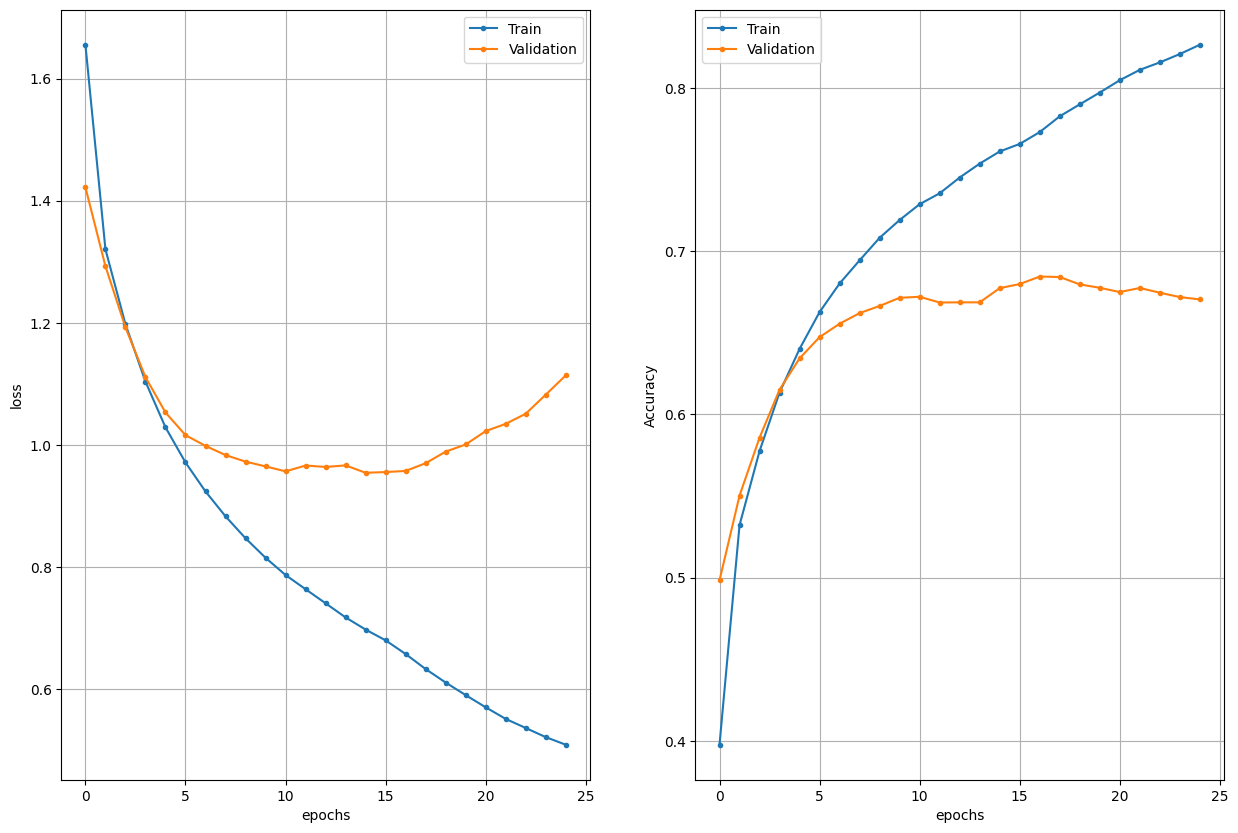

In [14]:
# Show training history (this cell is complete, nothing to implement here :-) )
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])

### Step 4: Evaluation

In this step, you have to calculate the accuracies and visualize some random samples. For the evaluation, you are going to use the test split from the dataset.

In [15]:
# Compute the labels and the predictions as sparse values

y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(x_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


In [16]:
# Compute and print the accuracy for each class
for class_id, class_name in classes.items():

    idx = (y_true == class_id)  # всі приклади цього класу
    acc = np.mean(y_pred[idx] == y_true[idx])

    print(class_name, acc)

plane 0.612
car 0.81
bird 0.562
cat 0.364
deer 0.673
dog 0.649
frog 0.761
horse 0.674
ship 0.836
truck 0.728


In [17]:
# Print the overall stats
ev = model.evaluate(x_test, y_test)
print('Test loss  ', ev[0])
print('Test metric', ev[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6669 - loss: 1.1389
Test loss   1.1388689279556274
Test metric 0.6668999791145325


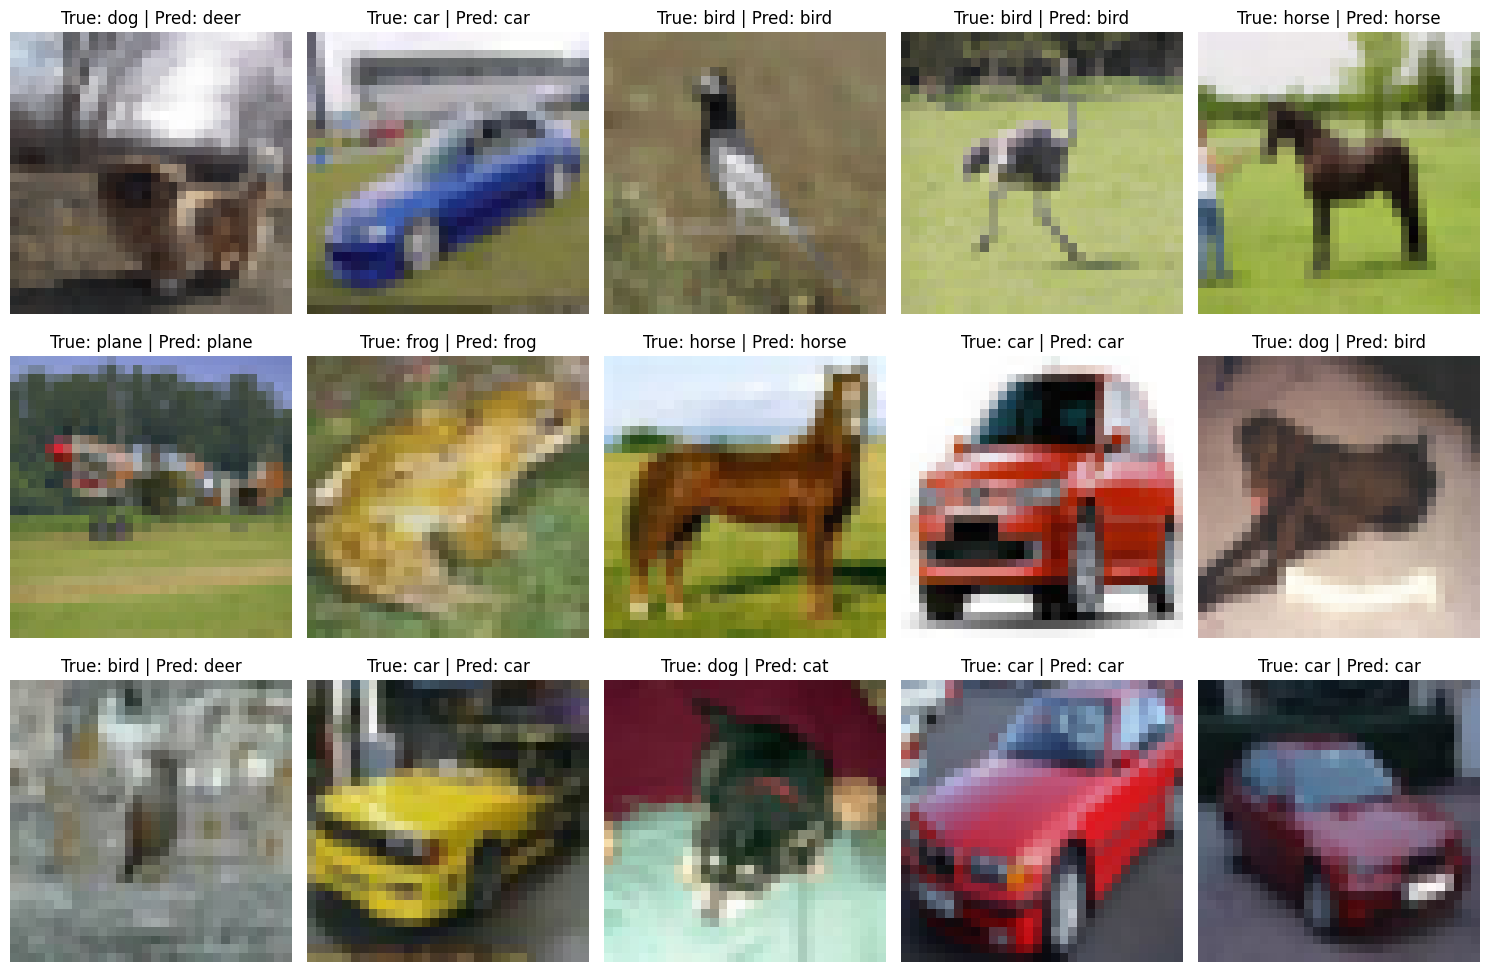

In [18]:
# Show random samples
for ii in range(15):
    # Pick a random sample
    idx = np.random.randint(0, x_test.shape[0])

    # Show the results
    plt.subplot(3,5,ii+1)
    plt.imshow(x_test[idx, ...])
    plt.title('True: ' + str(classes[y_true[idx]]) +
              ' | Pred: ' + str(classes[y_pred[idx]]))
    plt.axis("off")

plt.tight_layout()
plt.show()

### Questions
* What is the overall accuracy of the classifier?
* точность около 67%

* What modifications would you do in order to improve the classification accuracy?
 - *Точность классификации можно улучшить следующими способами:*
- *Использовать padding='same' для сохранения пространственной информации*
-*Добавить больше сверточных слоев*
- *Добавить слой Dropout для уменьшения переобучения*

* Make **one** modification (that you think can help) and train the classifier again. Does the accuracy improve?
- *Точность модели увеличилась с 66.7% до 68.9% после добавления padding='same' и Dropout, что подтверждает эффективность выбранных улучшений. Модель улучшеная  ниже*

In [19]:
inputs = Input(shape=(32, 32, 3))

x = Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
x = MaxPooling2D((2,2))(x)

x = Conv2D(64, (3,3), padding='same', activation='relu')(x)
x = MaxPooling2D((2,2))(x)

x = Flatten()(x)

x = Dense(64, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)

outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)

In [21]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=25,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 211ms/step - accuracy: 0.3128 - loss: 1.8579 - val_accuracy: 0.4916 - val_loss: 1.4940
Epoch 2/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 212ms/step - accuracy: 0.4213 - loss: 1.5726 - val_accuracy: 0.5467 - val_loss: 1.3309
Epoch 3/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 67s 213ms/step - accuracy: 0.4759 - loss: 1.4317 - val_accuracy: 0.5770 - val_loss: 1.2160
Epoch 4/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 221ms/step - accuracy: 0.5060 - loss: 1.3573 - val_accuracy: 0.6143 - val_loss: 1.1430
Epoch 5/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 205ms/step - accuracy: 0.5208 - loss: 1.3109 - val_accuracy: 0.6193 - val_loss: 1.1000
Epoch 6/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 205ms/step - accuracy: 0.5443 - loss: 1.2533 - val_accuracy: 0.6397 - val_loss: 1.0547
Epoch 7/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 214ms/step - accuracy: 0.5581 - loss: 1.2075 - val_accuracy: 0.6412 - val_loss: 1.0589
Epoch 8/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 65s 207ms/step - accuracy: 0.5644 - loss: 1

Train Acc      0.677049994468689
Validation Acc 0.6894999742507935


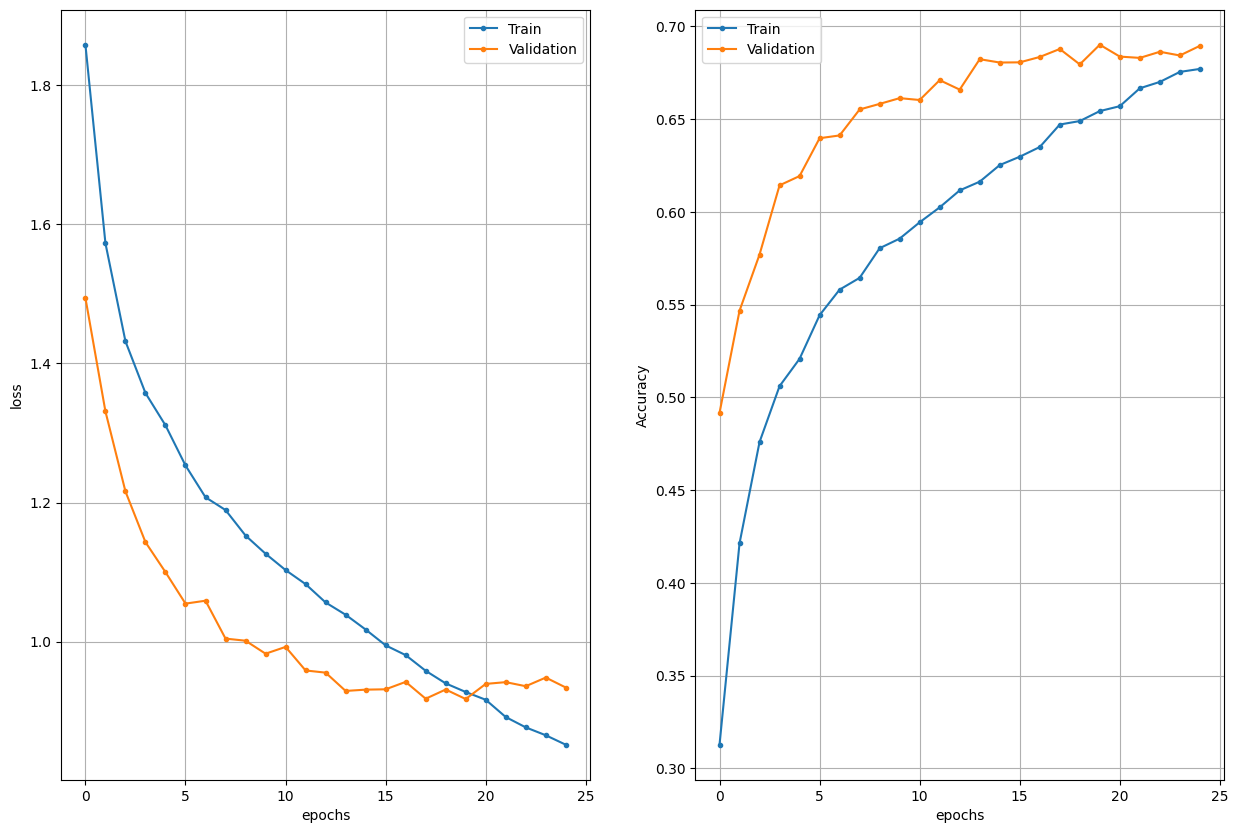

In [22]:
# Show training history (this cell is complete, nothing to implement here :-) )
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])

In [23]:
# Compute the labels and the predictions as sparse values

y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(x_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


In [24]:
# Compute and print the accuracy for each class
for class_id, class_name in classes.items():

    idx = (y_true == class_id)  # всі приклади цього класу
    acc = np.mean(y_pred[idx] == y_true[idx])

    print(class_name, acc)

plane 0.774
car 0.816
bird 0.525
cat 0.467
deer 0.54
dog 0.717
frog 0.677
horse 0.749
ship 0.837
truck 0.784


In [25]:
# Print the overall stats
ev = model.evaluate(x_test, y_test)
print('Test loss  ', ev[0])
print('Test metric', ev[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6886 - loss: 0.9414
Test loss   0.9413607716560364
Test metric 0.6886000037193298
